(17)=
# Chapter 17: Symbolic Mathematics with SymPy

**Topics Covered:**
- What symbolic math is and why it matters in ChE
- Defining symbols and building expressions with SymPy
- Simplification, expansion, and substitution
- Symbolic calculus: differentiation, integration, and limits
- Solving algebraic and differential equations
- ChE application: van der Waals equation of state and Gibbs energy
- `lambdify`: converting symbolic expressions to fast numerical functions

In [1]:
# ── All imports ──────────────────────────────────────────────────────────────
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing(use_unicode=True)   # pretty-print in Jupyter

(17.1)=
## 17.1 Motivation: Symbolic vs Numerical Math

In previous chapters, NumPy worked with **numbers** — floating-point approximations computed at runtime. SymPy works with **symbols** — exact mathematical objects that follow algebraic rules.

| | NumPy (numerical) | SymPy (symbolic) |
|---|---|---|
| Stores | Floating-point numbers | Exact expressions |
| `sqrt(2)` | `1.4142135...` | $\sqrt{2}$ (exact) |
| Derivative of $x^3$ | Not directly | $3x^2$ (exact) |
| Integral of $e^x$ | Numerical only | $e^x + C$ (exact) |
| Best for | Large arrays, speed | Derivations, exact answers |

**When do ChE engineers need symbolic math? (examples)**
- Deriving analytical expressions for $\frac{dP}{dT}$ or $\frac{dC_p}{dT}$ from an equation of state
- Integrating $C_p(T)$ exactly rather than numerically
- Solving the van der Waals equation for molar volume
- Finding steady-state solutions to ODEs before simulating them
- Verifying that a numerical answer has the right units and limiting behavior

In [1]:
import sympy as sp

sp.init_printing(use_unicode=True)   # pretty-print in Jupyter

(17.2)=
## 17.2 Symbols, Expressions, and Basic Operations

### 17.2.1 Defining Symbols

Everything in SymPy starts with `sp.symbols()`. A symbol is a named mathematical variable — it carries no numeric value until you assign one.

**Single and multiple symbols:**
```python
x = sp.symbols('x')              # single symbol
x, y, z = sp.symbols('x y z')    # multiple — space-separated string
x, y, z = sp.symbols('x, y, z')  # commas also work
```

In [3]:
x = sp.symbols('x')
print(x)
print(type(x))

x
<class 'sympy.core.symbol.Symbol'>


**Subscripts and Greek letters** use LaTeX naming conventions:
```python
x1, x2   = sp.symbols('x_1 x_2')      # subscripts render as x₁, x₂
alpha, beta = sp.symbols('alpha beta') # Greek letters
T_inf    = sp.symbols('T_inf')         # renders as T∞
```

**Assumptions** tell SymPy the mathematical domain of a symbol, enabling correct simplifications:
```python
T, P, V = sp.symbols('T P V', positive=True)  # T, P, V > 0
n       = sp.symbols('n', integer=True)        # n ∈ ℤ
x       = sp.symbols('x', real=True)           # x ∈ ℝ (no complex branches)
x       = sp.symbols('x', nonnegative=True)    # x ≥ 0
```


Without assumptions, SymPy treats every symbol as a general complex number. With assumptions, simplifications like $\sqrt{x^2} = x$ (valid only when $x \geq 0$) are applied automatically.

| Assumption | Domain | Common effect |
|------------|--------|---------------|
| `positive=True` | $x > 0$ | $\sqrt{x^2} \to x$; $\ln x$ is real |
| `nonnegative=True` | $x \geq 0$ | absorbs absolute values |
| `real=True` | $x \in \mathbb{R}$ | avoids complex branches in trig/log |
| `integer=True` | $x \in \mathbb{Z}$ | simplifies modular and floor expressions |
| `negative=True` | $x < 0$ | sign-aware simplifications |

**`symbols` vs `Symbol`:** `sp.symbols()` is the convenience form for one or more variables at once. The lower-level `sp.Symbol('x')` creates a single symbol and is equivalent to `sp.symbols('x')`:
```python
x = sp.Symbol('x', positive=True)    # same as sp.symbols('x', positive=True)
```

### 17.2.2 Building Expressions

Once you have symbols, you build expressions with ordinary Python operators. SymPy overloads `+`, `-`, `*`, `/`, `**` to produce symbolic objects instead of numbers.

In [ ]:
import sympy as sp
sp.init_printing(use_unicode=True)

In [25]:
# ── Single and multiple symbol definitions ────────────────────────────────────
x = sp.symbols('x')
x, y, z = sp.symbols('x y z')      # space-separated
a, b, c = sp.symbols('a, b, c')    # comma-separated (same result)

print("x:", x)
print("y:", y)
print("z:", z)
print("a:", a)
print("b:", b)
print("c:", c)

x: x
y: y
z: z
a: a
b: b
c: c


In [26]:
# ── Subscripts and Greek letters ──────────────────────────────────────────────
x1, x2   = sp.symbols('x_1 x_2')
alpha, beta = sp.symbols('alpha beta')
T_inf    = sp.symbols('T_inf')

print("Subscript symbols :", x1, x2)
print("Greek letters     :", alpha, beta)
print("Subscript-inf     :", T_inf)


Subscript symbols : x_1 x_2
Greek letters     : alpha beta
Subscript-inf     : T_inf


In [27]:
# ── Assumptions: effect on simplification ─────────────────────────────────────
x_gen = sp.symbols('x')                    # no assumption — general complex
x_pos = sp.symbols('x', positive=True)     # x > 0
x_real = sp.symbols('x', real=True)        # x ∈ ℝ

print("\nsqrt(x²) — no assumption :", sp.sqrt(x_gen**2))   # stays as sqrt(x**2)
print("sqrt(x²) — positive=True  :", sp.sqrt(x_pos**2))    # simplifies to x
print("sqrt(x²) — real=True      :", sp.sqrt(x_real**2))   # gives Abs(x)


sqrt(x²) — no assumption : sqrt(x**2)
sqrt(x²) — positive=True  : x
sqrt(x²) — real=True      : Abs(x)


In [28]:
# ── Symbol vs symbols ─────────────────────────────────────────────────────────
T = sp.Symbol('T', positive=True)   # single-symbol lower-level form
print("\nT is positive:", T.is_positive)


T is positive: True


Once you have symbols, you build expressions using standard Python operators — SymPy overloads `+`, `-`, `*`, `/`, `**` to return symbolic objects.

In [6]:
x, a, b, c = sp.symbols('x a b c')

# ── Define expressions used below ────────────────────────────────────────────
expr1 = x**2 + 2*x + 1          # x² + 2x + 1
expr3 = a*x**2 + b*x + c        # general quadratic

**Manipulating expressions:**

| Function | What it does | Example |
|----------|-------------|---------|
| `sp.expand(expr)` | Distributes and multiplies out | `(x+1)**3` → `x³+3x²+3x+1` |
| `sp.factor(expr)` | Factors into irreducibles | `x²-1` → `(x-1)(x+1)` |
| `sp.simplify(expr)` | Applies heuristics to reduce form | `(x²-1)/(x-1)` → `x+1` |
| `expr.subs(var, val)` | Substitutes a value for a symbol | `expr.subs(x, 3)` evaluates at $x=3$ |
| `expr.subs([(v1,n1), ...])` | Substitutes multiple values at once | `expr.subs([(a,1),(b,2)])` |

`subs` accepts both numeric values and other symbolic expressions — so you can evaluate at a number, substitute $\pi$, or replace one symbol with another.

In [8]:
# ── Key operations ────────────────────────────────────────────────────────────
print("── expand ──")
print(sp.expand((x + 1)**3))           # multiply out

print("\n── factor ──")
print(sp.factor(x**3 - x**2 - x + 1)) # factor into irreducibles

print("\n── simplify ──")
print(sp.simplify((x**2 - 1) / (x - 1)))   # cancel common factor

print("\n── substitute (subs) ──")
print(expr1.subs(x, 3))                # evaluate at x = 3  → integer
print(expr1.subs(x, sp.pi))            # substitute symbolic value

print("\n── substitute multiple values ──")
print(expr3.subs([(a, 1), (b, -3), (c, 2)]))  # plug in all at once

── expand ──
x**3 + 3*x**2 + 3*x + 1

── factor ──
(x - 1)**2*(x + 1)

── simplify ──
x + 1

── substitute (subs) ──
16
1 + 2*pi + pi**2

── substitute multiple values ──
x**2 - 3*x + 2


### 17.2.3 Exact Arithmetic

SymPy never rounds. Fractions stay as fractions, $\pi$ stays as $\pi$, and $\sqrt{2}$ stays as $\sqrt{2}$ until you explicitly ask for a decimal.

**Exact numeric types:**

| Syntax | What it creates | Example |
|--------|----------------|---------|
| `sp.Rational(p, q)` | Exact fraction $p/q$ | `sp.Rational(1, 3)` → $\frac{1}{3}$ |
| `sp.sqrt(n)` | Exact square root, simplified | `sp.sqrt(8)` → $2\sqrt{2}$ |
| `sp.pi` | Symbolic $\pi$ | stays as $\pi$ in expressions |
| `sp.E` | Symbolic $e$ (Euler's number) | stays as $e$ in expressions |
| `sp.oo` | Symbolic $\infty$ | used in limits and integrals |
| `sp.I` | Imaginary unit $i$ | `sp.I**2` → $-1$ |

In [9]:
# ── Exact arithmetic ─────────────────────────────────────────────────────────
print("Python float  :", 1/3 + 1/6)          # 0.5 (rounded)
print("SymPy rational:", sp.Rational(1,3) + sp.Rational(1,6))  # 1/2 (exact)

print("\nsqrt(8) =", sp.sqrt(8))              # 2√2  (exact)
print("pi      =", sp.pi)   # π

print("\nsp.E =", sp.E)     # Euler's number, exact

Python float  : 0.5
SymPy rational: 1/2

sqrt(8) = 2*sqrt(2)
pi      = pi

sp.E = E


**Converting to decimals:**

```python
sp.N(expr)          # evaluate to 15 significant figures (default)
sp.N(expr, n)       # evaluate to n significant figures
expr.evalf()        # same as sp.N(expr) — method form
expr.evalf(n)       # same as sp.N(expr, n)
```

Both `sp.N()` and `.evalf()` do the same thing — `sp.N` is the function form, `.evalf()` is the method form. Neither modifies the original expression; they return a floating-point SymPy number (`Float`).

The key difference from Python's built-in float arithmetic is that SymPy tracks exact values symbolically first and only converts to decimal when you ask:

```python
1/3 + 1/6               # Python float: 0.5 (may accumulate rounding error)
sp.Rational(1,3) + sp.Rational(1,6)  # SymPy: 1/2  (exact)
```

In [10]:
print("pi (50 digits):", sp.N(sp.pi, 50))     # numerical to 50 sig figs
                    
print("exp(1) numerical:", sp.N(sp.E, 15))    # 2.71828182845905

pi (50 digits): 3.1415926535897932384626433832795028841971693993751
exp(1) numerical: 2.71828182845905


(17.3)=
## 17.3 Symbolic Calculus

### 17.3.1 Differentiation

`sp.diff(expr, var)` differentiates `expr` with respect to `var`. Pass an integer as a third argument for higher-order derivatives.

$$
\frac{d}{dx}\left[x^n\right] = n x^{n-1}, \qquad
\frac{d^n}{dx^n}\left[e^x\right] = e^x
$$

**Syntax:**

```python
sp.diff(expr, x)        # first derivative w.r.t. x
sp.diff(expr, x, 2)     # second derivative (d²/dx²)
sp.diff(expr, x, n)     # n-th derivative
```

In [11]:
x = sp.symbols('x')

# ── First derivatives ─────────────────────────────────────────────────────────
print("d/dx [x^4]          =", sp.diff(x**4, x))
print("d/dx [sin(x)]       =", sp.diff(sp.sin(x), x))
print("d/dx [exp(-x^2)]    =", sp.diff(sp.exp(-x**2), x))
print("d/dx [ln(x)]        =", sp.diff(sp.ln(x), x))
print("d/dx [x^2 * sin(x)] =", sp.diff(x**2 * sp.sin(x), x))   # product rule

# ── Higher-order derivatives ──────────────────────────────────────────────────
print("\nd²/dx² [sin(x)] =", sp.diff(sp.sin(x), x, 2))
print("d³/dx³ [x^5]    =", sp.diff(x**5, x, 3))

d/dx [x^4]          = 4*x**3
d/dx [sin(x)]       = cos(x)
d/dx [exp(-x^2)]    = -2*x*exp(-x**2)
d/dx [ln(x)]        = 1/x
d/dx [x^2 * sin(x)] = x**2*cos(x) + 2*x*sin(x)

d²/dx² [sin(x)] = -sin(x)
d³/dx³ [x^5]    = 60*x**2


For **partial derivatives**, just pass a different symbol — SymPy treats all other symbols as constants:

```python
sp.diff(expr, T)        # ∂expr/∂T  (all other symbols held constant)
sp.diff(expr, V)        # ∂expr/∂V
```

For **mixed partial derivatives**, chain the variables:

```python
sp.diff(expr, x, y)     # ∂²expr/∂x∂y
sp.diff(expr, x, 2, y)  # ∂³expr/∂x²∂y
```

The result is always a new symbolic expression that can be simplified, substituted into, or passed to `lambdify` like any other SymPy expression.

In [12]:
# ── Partial derivatives ───────────────────────────────────────────────────────
T, V = sp.symbols('T V', positive=True)
R, a_vdw, b_vdw = sp.symbols('R a b', positive=True)

# Ideal gas pressure: P = RT/V
P_ideal = R * T / V
print("\n∂P/∂T (ideal gas) =", sp.diff(P_ideal, T))
print("∂P/∂V (ideal gas) =", sp.diff(P_ideal, V))


∂P/∂T (ideal gas) = R/V
∂P/∂V (ideal gas) = -R*T/V**2


### 17.3.2 Integration

`sp.integrate(expr, var)` returns the **indefinite integral** (no constant of integration is shown but it is implied). For a **definite integral**, pass a tuple `(var, lower, upper)`.

$$
\int x^n \, dx = \frac{x^{n+1}}{n+1} + C, \qquad
\int_a^b f(x)\, dx = F(b) - F(a)
$$

**Syntax:**

```python
sp.integrate(expr, x)              # indefinite integral w.r.t. x  (+ C implied)
sp.integrate(expr, (x, a, b))      # definite integral from a to b
sp.integrate(expr, (x, 0, sp.oo))  # improper integral to ∞
```

Limits can be numeric, symbolic, or SymPy constants like `sp.pi` and `sp.oo`:

```python
sp.integrate(sp.sin(x), (x, 0, sp.pi))   # definite: limits are sp.pi and 0
sp.integrate(sp.exp(-x), (x, 0, sp.oo))  # improper: upper limit is ∞
sp.integrate(f, (x, a, b))               # symbolic limits — result stays symbolic
```

For **multiple integrals**, chain the variable tuples:

```python
sp.integrate(expr, (x, 0, 1), (y, 0, 1))   # ∫₀¹ ∫₀¹ expr dy dx
```

If SymPy cannot find a closed-form antiderivative, it returns the integral unevaluated as an `Integral` object rather than raising an error. You can then evaluate it numerically with `.evalf()`.

In [14]:
x, T = sp.symbols('x T', positive=True)

# ── Indefinite integrals ──────────────────────────────────────────────────────
print("∫ x^3 dx        =", sp.integrate(x**3, x))
print("∫ sin(x) dx     =", sp.integrate(sp.sin(x), x))
print("∫ exp(-x) dx    =", sp.integrate(sp.exp(-x), x))
print("∫ 1/x dx        =", sp.integrate(1/x, x))

# ── Definite integrals ────────────────────────────────────────────────────────
print("\n∫₀^π sin(x) dx =", sp.integrate(sp.sin(x), (x, 0, sp.pi)))   # → 2
print("∫₀^∞ exp(-x) dx =", sp.integrate(sp.exp(-x), (x, 0, sp.oo)))  # → 1

# ── ChE application: exact ΔH from a Cp polynomial fit ───────────────────────
# Cp(T) ≈ 20.71 + 0.06745 T - 4.498e-5 T² + 1.119e-8 T³  (CO2, J/mol/K)
Cp = 20.71 + 0.06745*T - 4.498e-5*T**2 + 1.119e-8*T**3

dH = sp.integrate(Cp, (T, 400, 900))
print(f"\nΔH = ∫₄₀₀⁹⁰⁰ Cp dT = {float(dH):.2f} J/mol  =  {float(dH)/1000:.4f} kJ/mol")

∫ x^3 dx        = x**4/4
∫ sin(x) dx     = -cos(x)
∫ exp(-x) dx    = -exp(-x)
∫ 1/x dx        = log(x)

∫₀^π sin(x) dx = 2
∫₀^∞ exp(-x) dx = 1

ΔH = ∫₄₀₀⁹⁰⁰ Cp dT = 24069.51 J/mol  =  24.0695 kJ/mol


### 17.3.3 Limits

The limit of a function $f(x)$ as $x$ approaches a point $a$ is written:

$$\lim_{x \to a} f(x) = L$$

One-sided limits approach $a$ from one direction only:

$$\lim_{x \to a^+} f(x) \qquad \text{(from the right)} \qquad \lim_{x \to a^-} f(x) \qquad \text{(from the left)}$$

The two-sided limit $L$ exists if and only if both one-sided limits exist and are equal:

$$\lim_{x \to a^+} f(x) = \lim_{x \to a^-} f(x) = L$$

`sp.limit(expr, var, point)` evaluates the limit as `var → point`. Use `sp.oo` for $\infty$ and pass `'+'` or `'-'` as a fourth argument for one-sided limits.

**Syntax:**

```python
sp.limit(expr, x, point)       # two-sided limit as x → point
sp.limit(expr, x, 0, '+')      # one-sided limit from the right (x → 0⁺)
sp.limit(expr, x, 0, '-')      # one-sided limit from the left  (x → 0⁻)
sp.limit(expr, x, sp.oo)       # limit as x → ∞
sp.limit(expr, x, -sp.oo)      # limit as x → -∞
```

The `point` argument can be any numeric value, a symbolic expression, or a SymPy constant:

```python
sp.limit(expr, x, 0)           # x → 0
sp.limit(expr, x, sp.pi)       # x → π
sp.limit(expr, x, sp.oo)       # x → ∞
sp.limit(expr, x, a)           # x → a  (symbolic, result stays in terms of a)
```

If the two one-sided limits differ, `sp.limit` returns the right-hand limit by default. To check whether a limit exists, compare the `'+'` and `'-'` results explicitly.

In [43]:
x = sp.symbols('x')

# ── Classic limits ────────────────────────────────────────────────────────────
print("lim x→0  sin(x)/x      =", sp.limit(sp.sin(x)/x, x, 0))         # → 1
print("lim x→∞  (1 + 1/x)^x  =", sp.limit((1 + 1/x)**x, x, sp.oo))    # → e
print("lim x→0+ ln(x)         =", sp.limit(sp.ln(x), x, 0, '+'))        # → -∞
print("lim x→∞  exp(-x)       =", sp.limit(sp.exp(-x), x, sp.oo))       # → 0

# ── ChE application: limiting ideal-gas behavior of van der Waals ─────────────
# P = RT/(V-b) - a/V²  as V→∞ should recover P → RT/V  (ideal gas)
R_s, T_s, V_s, a_s, b_s = sp.symbols('R T V a b', positive=True)
P_vdw = R_s*T_s/(V_s - b_s) - a_s/V_s**2

P_limit = sp.limit(P_vdw * V_s / (R_s * T_s), V_s, sp.oo)
print("\nlim V→∞  PV/(RT) for van der Waals =", P_limit, "  (→ 1 = ideal gas ✓)")

lim x→0  sin(x)/x      = 1
lim x→∞  (1 + 1/x)^x  = E
lim x→0+ ln(x)         = -oo
lim x→∞  exp(-x)       = 0

lim V→∞  PV/(RT) for van der Waals = 1   (→ 1 = ideal gas ✓)


(17.4)=
## 17.4 Solving Equations

### 17.4.1 Algebraic Equations with `sp.solve`

Solving an algebraic equation means finding all values of $x$ that satisfy:

$$f(x) = 0$$

For a single-variable polynomial of degree $n$, there are at most $n$ solutions (roots). The classic example is the **quadratic equation**:

$$ax^2 + bx + c = 0 \implies x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$

For a **system of equations** in multiple unknowns, we seek $(x, y, \ldots)$ satisfying all equations simultaneously:

$$\begin{cases} f_1(x,\, y) = 0 \\ f_2(x,\, y) = 0 \end{cases}$$

A unique solution exists when the number of independent equations equals the number of unknowns.

`sp.solve(equation, variable)` returns all symbolic solutions to `equation = 0`. Pass an `sp.Eq(lhs, rhs)` object or just the expression (SymPy assumes it equals zero).

| Call | Meaning |
|------|---------|
| `sp.solve(expr, x)` | Solve $f(x) = 0$ for $x$ |
| `sp.solve(sp.Eq(lhs, rhs), x)` | Solve $\text{lhs} = \text{rhs}$ for $x$ |
| `sp.solve([eq1, eq2], [x, y])` | Solve a system $f_1 = 0,\; f_2 = 0$ |

In [ ]:
x, y = sp.symbols('x y')
a, b, c = sp.symbols('a b c')

# ── Quadratic formula ─────────────────────────────────────────────────────────
print("Roots of ax² + bx + c = 0:")
roots = sp.solve(a*x**2 + b*x + c, x)
for r in roots:
    print(" ", r)

# ── Specific numerical example ────────────────────────────────────────────────
print("\nRoots of x² - 5x + 6 = 0:", sp.solve(x**2 - 5*x + 6, x))

# ── System of equations ───────────────────────────────────────────────────────
# 2x + 3y = 7
# x  - y  = 1
eq1 = sp.Eq(2*x + 3*y, 7) # 2x+3y = 7
eq2 = sp.Eq(x - y, 1) # x-y = 1
sol = sp.solve([eq1, eq2], [x, y])
print("\nSystem solution:", sol)
# verification
sol1 = 2*sol[x] + 3*sol[y] 
sol2 = sol[x] - sol[y]
print("Check eq1: 2x + 3y =", sol1, "→", sol1.doit())
print("Check eq2: x - y   =", sol2, "→", sol2.doit())


# ── ChE: solve ideal gas for V ────────────────────────────────────────────────
P, V, R_s, T_s, n = sp.symbols('P V R T n', positive=True)
ideal_gas = sp.Eq(P*V, n*R_s*T_s) # PV = nRT
V_sol = sp.solve(ideal_gas, V)
print("\nIdeal gas V =", V_sol[0])

Roots of ax² + bx + c = 0:
  (-b - sqrt(-4*a*c + b**2))/(2*a)
  (-b + sqrt(-4*a*c + b**2))/(2*a)

Roots of x² - 5x + 6 = 0: [2, 3]

System solution: {x: 2, y: 1}
Check eq1: 2x + 3y = 7 → 7
Check eq2: x - y   = 1 → 1

Ideal gas V = R*T*n/P


### 17.4.2 Ordinary Differential Equations with `sp.dsolve` --> Let's revisit this later!

`sp.dsolve(ode, func)` solves ordinary differential equations symbolically. You define the unknown function with `sp.Function` and write the ODE using `func(x).diff(x)`.

This is useful for:
- First-order decay / growth models (radioactive decay, first-order reactions)
- Finding the analytical steady-state of a CSTR or batch reactor
- Verifying numerical ODE solutions against exact answers

In [17]:
t, k = sp.symbols('t k', positive=True)
C = sp.Function('C')    # C is the unknown function of t

# ── First-order reaction: dC/dt = -k*C ───────────────────────────────────────
ode1 = sp.Eq(C(t).diff(t), -k * C(t))
sol1 = sp.dsolve(ode1, C(t))
print("dC/dt = -kC  →  ", sol1)

# Apply initial condition C(0) = C0
C0 = sp.Symbol('C0', positive=True)
C1_const = sp.solve(sol1.rhs.subs(t, 0) - C0, sp.Symbol('C1'))[0]
C_exact = sol1.rhs.subs(sp.Symbol('C1'), C1_const)
print("With C(0)=C0  →  C(t) =", C_exact)

# ── Second-order ODE: d²y/dx² + y = 0  (harmonic oscillator) ─────────────────
x = sp.symbols('x')
y = sp.Function('y')
ode2 = sp.Eq(y(x).diff(x, 2) + y(x), 0)
sol2 = sp.dsolve(ode2, y(x))
print("\nd²y/dx² + y = 0  →  ", sol2)

# ── Energy balance ODE: dT/dt = (Q - UA(T-Tc)) / (m*Cp) ──────────────────────
# Simplified: dT/dt = alpha - beta*T  (first-order linear)
T_f = sp.Function('T')
alpha, beta = sp.symbols('alpha beta', positive=True)
ode3 = sp.Eq(T_f(t).diff(t), alpha - beta*T_f(t))
sol3 = sp.dsolve(ode3, T_f(t))
print("\ndT/dt = α - βT  →  ", sol3)
print("  (steady state T_ss = α/β as t→∞ ✓)")

dC/dt = -kC  →   Eq(C(t), C1*exp(-k*t))
With C(0)=C0  →  C(t) = C0*exp(-k*t)

d²y/dx² + y = 0  →   Eq(y(x), C1*sin(x) + C2*cos(x))

dT/dt = α - βT  →   Eq(T(t), C1*exp(-beta*t) + alpha/beta)
  (steady state T_ss = α/β as t→∞ ✓)


(17.5)=
## 17.5 ChE Application: van der Waals Equation of State

The **van der Waals equation** corrects the ideal gas law for molecular volume ($b$) and intermolecular attractions ($a$):

$$
\left(P + \frac{a}{V^2}\right)(V - b) = RT
\qquad \Longleftrightarrow \qquad
P = \frac{RT}{V - b} - \frac{a}{V^2}
$$

This is a **cubic** equation in $V$ — it has up to three real roots, corresponding to liquid, two-phase, and vapor states. SymPy can:
1. Rearrange it into cubic form
2. Solve analytically for $V$
3. Compute $\left(\frac{\partial P}{\partial V}\right)_T$ for spinodal and critical-point analysis
4. Find the critical point where $\frac{\partial P}{\partial V} = \frac{\partial^2 P}{\partial V^2} = 0$

In [ ]:
P, V, T_s, R_s, a_s, b_s = sp.symbols('P V T R a b', positive=True)

# ── van der Waals pressure ────────────────────────────────────────────────────
P_vdw = R_s*T_s / (V - b_s) - a_s / V**2
print("P(V) =", P_vdw)

# ── Solve analytically for V (cubic roots) ───────────────────────────────────
# van der Waals rearranges to: P*V³ - (Pb + RT)*V² + a*V - ab = 0
V_solutions = sp.solve(P_vdw - P, V) # R*T / (V - b) - a / V**2 - P = 0
print("\nAnalytic roots V(P,T):")
for k, sol in enumerate(V_solutions):
    print(f"  V_{k+1} =", sol)

# ── dP/dV at constant T (spinodal condition: dP/dV = 0) ─────────────────────
dPdV = sp.diff(P_vdw, V)
print("\ndP/dV =", sp.simplify(dPdV))

# ── d²P/dV² ──────────────────────────────────────────────────────────────────
d2PdV2 = sp.diff(P_vdw, V, 2)
print("\nd²P/dV² =", sp.simplify(d2PdV2))

# ── Critical point: solve dP/dV = 0 and d²P/dV² = 0 simultaneously ──────────
V_c, T_c = sp.symbols('V_c T_c', positive=True)

crit_eq1 = dPdV.subs([(V, V_c), (T_s, T_c)])
crit_eq2 = d2PdV2.subs([(V, V_c), (T_s, T_c)])

crit_sol = sp.solve([crit_eq1, crit_eq2], [V_c, T_c])

if isinstance(crit_sol, list):
    crit_sol = crit_sol[0]
    Vc_val = crit_sol[0]
    Tc_val = crit_sol[1]
else:
    Vc_val = crit_sol[V_c]
    Tc_val = crit_sol[T_c]

print("\nCritical point:")
print("  V_c =", Vc_val)
print("  T_c =", Tc_val)

P_c = P_vdw.subs([(V, Vc_val), (T_s, Tc_val)])
print("  P_c =", sp.simplify(P_c))

P(V) = R*T/(V - b) - a/V**2

Analytic roots V(P,T):
  V_1 = -(-3*a/P + (-P*b - R*T)**2/P**2)/(3*(sqrt(-4*(-3*a/P + (-P*b - R*T)**2/P**2)**3 + (-27*a*b/P - 9*a*(-P*b - R*T)/P**2 + 2*(-P*b - R*T)**3/P**3)**2)/2 - 27*a*b/(2*P) - 9*a*(-P*b - R*T)/(2*P**2) + (-P*b - R*T)**3/P**3)**(1/3)) - (sqrt(-4*(-3*a/P + (-P*b - R*T)**2/P**2)**3 + (-27*a*b/P - 9*a*(-P*b - R*T)/P**2 + 2*(-P*b - R*T)**3/P**3)**2)/2 - 27*a*b/(2*P) - 9*a*(-P*b - R*T)/(2*P**2) + (-P*b - R*T)**3/P**3)**(1/3)/3 - (-P*b - R*T)/(3*P)
  V_2 = -(-3*a/P + (-P*b - R*T)**2/P**2)/(3*(-1/2 - sqrt(3)*I/2)*(sqrt(-4*(-3*a/P + (-P*b - R*T)**2/P**2)**3 + (-27*a*b/P - 9*a*(-P*b - R*T)/P**2 + 2*(-P*b - R*T)**3/P**3)**2)/2 - 27*a*b/(2*P) - 9*a*(-P*b - R*T)/(2*P**2) + (-P*b - R*T)**3/P**3)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(sqrt(-4*(-3*a/P + (-P*b - R*T)**2/P**2)**3 + (-27*a*b/P - 9*a*(-P*b - R*T)/P**2 + 2*(-P*b - R*T)**3/P**3)**2)/2 - 27*a*b/(2*P) - 9*a*(-P*b - R*T)/(2*P**2) + (-P*b - R*T)**3/P**3)**(1/3)/3 - (-P*b - R*T)/(3*P)
  V_3 = -(-3*a/P +

### 17.5.1 Plotting the van der Waals P–V Isotherm

Using the symbolic expression and `lambdify`, we can plot isotherms for CO$_2$ ($a = 0.3658$ J·m³/mol², $b = 4.286\times10^{-5}$ m³/mol) and visualize the phase transition region.

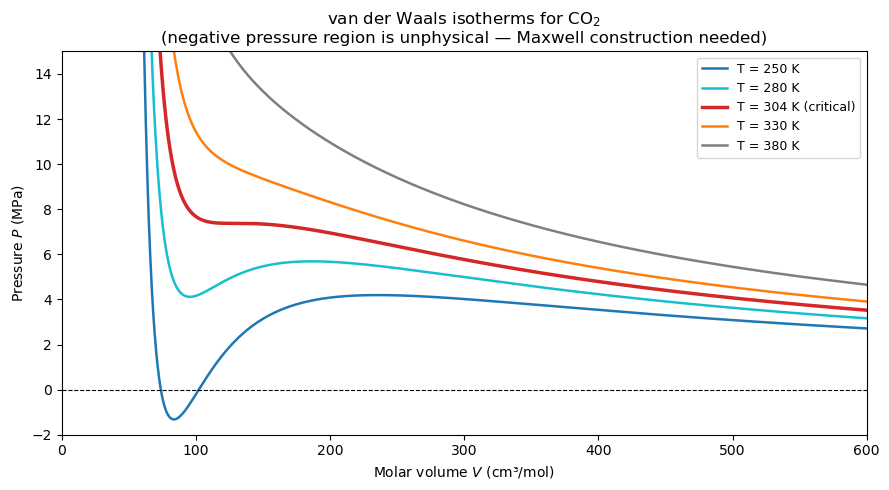

CO₂ critical temperature: T_c = 304.2 K  (31.0 °C)
CO₂ critical pressure:    P_c = 7.38 MPa


In [51]:
import numpy as np
import matplotlib.pyplot as plt

# CO2 van der Waals constants
a_co2 = 0.3658       # J·m³/mol²
b_co2 = 4.286e-5     # m³/mol
R_val = 8.314        # J/(mol·K)
T_c_co2 = 8 * a_co2 / (27 * R_val * b_co2)   # ≈ 304 K  (critical temp)

# Convert symbolic P_vdw → fast numerical function
P_num = sp.lambdify((V, T_s, R_s, a_s, b_s), P_vdw, 'numpy')

V_arr = np.linspace(1.1*b_co2, 6e-4, 2000)   # m³/mol

fig, ax = plt.subplots(figsize=(9, 5))
for T_val, color in zip([250, 280, T_c_co2, 330, 380],
                        ['tab:blue', 'tab:cyan', 'tab:red', 'tab:orange', 'tab:gray']):
    P_arr = P_num(V_arr, T_val, R_val, a_co2, b_co2) / 1e6   # Pa → MPa
    label = f'T = {T_val:.0f} K' + (' (critical)' if abs(T_val - T_c_co2) < 1 else '')
    lw = 2.5 if abs(T_val - T_c_co2) < 1 else 1.8
    ax.plot(V_arr * 1e6, P_arr, color=color, linewidth=lw, label=label)  # V in cm³/mol

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlim(0, 600); ax.set_ylim(-2, 15)
ax.set_xlabel('Molar volume $V$ (cm³/mol)')
ax.set_ylabel('Pressure $P$ (MPa)')
ax.set_title('van der Waals isotherms for CO$_2$\n(negative pressure region is unphysical — Maxwell construction needed)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"CO₂ critical temperature: T_c = {T_c_co2:.1f} K  ({T_c_co2-273.15:.1f} °C)")
print(f"CO₂ critical pressure:    P_c = {a_co2/(27*b_co2**2)/1e6:.2f} MPa")

(17.6)=
## 17.6 `lambdify`: Bridging SymPy and NumPy

The key workflow: **derive symbolically → convert to a fast numerical function with `lambdify` → evaluate or plot**.

SymPy expressions are **symbolic objects** — they cannot be evaluated on NumPy arrays directly. `sp.lambdify` converts a symbolic expression into a regular Python function backed by NumPy (or any other numerical library), giving you the best of both worlds: symbolic derivation + numerical speed.

```python
f_num = sp.lambdify(variables, expression, 'numpy')
```

| Argument | Description |
|----------|-------------|
| `variables` | Symbol or tuple of symbols — become function arguments |
| `expression` | Any SymPy expression |
| `'numpy'` | Backend: `'numpy'` (default), `'scipy'`, `'math'`, or a dict |

**Typical workflow:**
1. Define symbols and derive the expression symbolically (e.g., take a derivative, integrate, simplify)
2. Call `lambdify` to get a fast numerical function
3. Evaluate on arrays, plot, or pass to a solver

**Syntax examples — single variable, multiple variables, and scalar evaluation:**

```python
# Single variable
f_num = sp.lambdify(x, expr, 'numpy')      # f_num(x_val)

# Multiple variables — pass a tuple
g_num = sp.lambdify((x, y), expr, 'numpy') # g_num(x_val, y_val)

# Evaluate at a scalar
f_num(2.0)                                  # returns a float

# Evaluate on a NumPy array (vectorized automatically)
x_arr = np.linspace(0, 10, 500)
f_num(x_arr)                                # returns an array
```

The backend argument controls which library is used under the hood:

| Backend | When to use |
|---------|-------------|
| `'numpy'` | Default — arrays, plotting |
| `'math'` | Scalar-only (no arrays) |
| `'scipy'` | When the expression uses special functions (e.g. `erf`, `jv`) |

In [8]:
import numpy as np
import sympy as sp

x, y = sp.symbols('x y')

# ── Single-variable lambdify ──────────────────────────────────────────────────
expr = x**2 + sp.sin(x)
f_num = sp.lambdify(x, expr, 'numpy')

def f_numpy(x):
    return x**2 + np.sin(x)

print("f(x) =", expr)
print("f(1.0) =", f_num(1.0))                        # scalar
print("f([0,1,2]) =", f_num(np.array([0.0, 1.0, 2.0])))  # array
print("numpy f_numpy([0,1,2]) =", f_numpy(np.array([0.0, 1.0, 2.0])))
# ── Multi-variable lambdify ───────────────────────────────────────────────────
expr2 = x**2 + y**2
g_num = sp.lambdify((x, y), expr2, 'numpy')

print("\ng(x,y) =", expr2)
print("g(3, 4) =", g_num(3, 4))                       # → 25

# ── Lambdify a derivative ─────────────────────────────────────────────────────
df_sym = sp.diff(expr, x)
df_num = sp.lambdify(x, df_sym, 'numpy')

print("\nf'(x) =", df_sym)
print("f'(0) =", df_num(0.0))                         # → 1.0  (0 + cos(0))
print("f'(π) =", df_num(float(sp.pi)))                # → 2π - 1

f(x) = x**2 + sin(x)
f(1.0) = 1.8414709848078965
f([0,1,2]) = [0.         1.84147098 4.90929743]
numpy f_numpy([0,1,2]) = [0.         1.84147098 4.90929743]

g(x,y) = x**2 + y**2
g(3, 4) = 25

f'(x) = 2*x + cos(x)
f'(0) = 1.0
f'(π) = 5.283185307179586


f(x)   = exp(-x/3)*sin(x)
f'(x)  = -exp(-x/3)*sin(x)/3 + exp(-x/3)*cos(x)
f''(x) = -2*(4*sin(x) + 3*cos(x))*exp(-x/3)/9


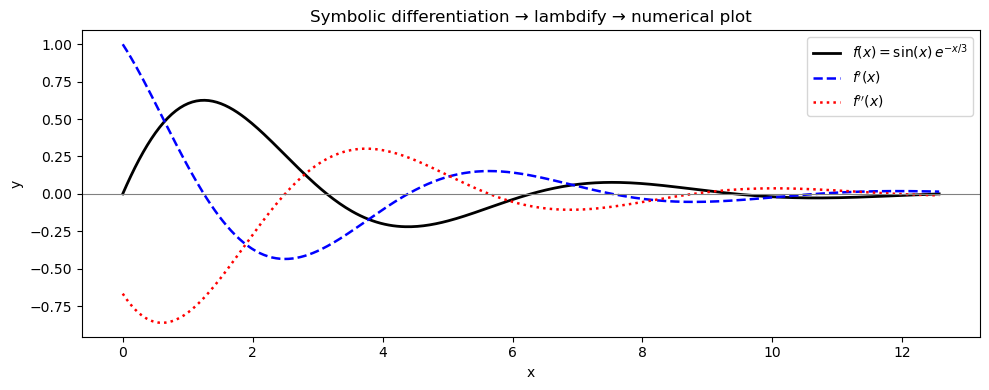


Critical points of f(x) on [0, 4π]:
  x = 1.2490,  f(x) = 0.6256,  f'(x) ≈ -9.32e-14
  x = 4.3906,  f(x) = -0.2195,  f'(x) ≈ -2.84e-14
  x = 7.5322,  f(x) = 0.0770,  f'(x) ≈ 4.75e-16
  x = 10.6738,  f(x) = -0.0270,  f'(x) ≈ 2.03e-16


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')

# ── Step 1: derive symbolically ───────────────────────────────────────────────
f_sym   = sp.sin(x) * sp.exp(-x / 3)
df_sym  = sp.diff(f_sym, x)
d2f_sym = sp.diff(f_sym, x, 2)

print("f(x)   =", f_sym)
print("f'(x)  =", df_sym)
print("f''(x) =", d2f_sym)

# ── Step 2: convert to numerical functions ────────────────────────────────────
f   = sp.lambdify(x, f_sym,   'numpy')
df  = sp.lambdify(x, df_sym,  'numpy')
d2f = sp.lambdify(x, d2f_sym, 'numpy')

# ── Step 3: evaluate and plot ─────────────────────────────────────────────────
x_arr = np.linspace(0, 4*np.pi, 400)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_arr, f(x_arr),   'k-',  linewidth=2,   label=r'$f(x) = \sin(x)\,e^{-x/3}$')
ax.plot(x_arr, df(x_arr),  'b--', linewidth=1.8, label=r"$f'(x)$")
ax.plot(x_arr, d2f(x_arr), 'r:',  linewidth=1.8, label=r"$f''(x)$")
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Symbolic differentiation → lambdify → numerical plot')
ax.legend()
plt.tight_layout()
plt.show()

# ── Find zeros of f'(x) numerically using the lambdified derivative ───────────
from scipy.optimize import brentq
zeros = []
for i in range(len(x_arr) - 1):
    if df(x_arr[i]) * df(x_arr[i+1]) < 0:   # sign change → root
        root = brentq(df, x_arr[i], x_arr[i+1])
        zeros.append(root)

print("\nCritical points of f(x) on [0, 4π]:")
for z in zeros:
    print(f"  x = {z:.4f},  f(x) = {f(z):.4f},  f'(x) ≈ {df(z):.2e}")

(17.7)=
## 17.7 Summary

| Concept | SymPy tool | Example |
|---------|-----------|---------|
| **Define symbols** | `sp.symbols('x y', positive=True)` | Variables with assumptions |
| **Exact arithmetic** | `sp.Rational`, `sp.pi`, `sp.E` | $\frac{1}{3} + \frac{1}{6} = \frac{1}{2}$ exactly |
| **Expand** | `sp.expand(expr)` | $(x+1)^3 \to x^3 + 3x^2 + 3x + 1$ |
| **Factor** | `sp.factor(expr)` | $x^2 - 1 \to (x-1)(x+1)$ |
| **Simplify** | `sp.simplify(expr)` | Cancel, trig identities, etc. |
| **Substitute** | `expr.subs(x, val)` | Plug in a value or another symbol |
| **Differentiate** | `sp.diff(expr, x, n)` | $n$-th derivative w.r.t. $x$ |
| **Integrate** | `sp.integrate(expr, x)` | Indefinite; `(x, a, b)` for definite |
| **Limit** | `sp.limit(expr, x, pt)` | $\lim_{x\to 0}\frac{\sin x}{x} = 1$ |
| **Solve algebraic** | `sp.solve(eq, x)` | Roots, quadratic formula, systems |
| **Solve ODE** | `sp.dsolve(ode, f(x))` | Analytical solution with constant $C_1$ |
| **Numerical eval** | `expr.evalf(n)` or `sp.N(expr, n)` | $\pi$ to 50 digits |
| **Vectorize** | `sp.lambdify(x, expr, 'numpy')` | SymPy → NumPy-compatible function |

**Golden rule:** Use SymPy to *derive* — exact formulas, derivatives, integrals, and solutions. Use NumPy/SciPy to *compute* — fast array operations, plotting, and numerical solvers. Connect the two with `lambdify`.

**ChE use cases covered:**
- $\partial P / \partial T$ and $\partial P / \partial V$ from the ideal gas and van der Waals EOS
- Exact $\Delta H = \int C_p\, dT$ from a polynomial fit
- Critical point $(V_c, T_c, P_c)$ of van der Waals gas from $\nabla P = 0$
- First-order reaction $dC/dt = -kC$ solved analytically
- Reactor energy balance ODE solved to find steady-state temperature